#  **Setup and LOAD DATA**

In [2]:
import tensorflow as tf
import os



TensorFlow Version: 2.19.0
GPUs Available:  2


In [6]:
import cv2

# Set the path to my dataset 
data_dir = '/kaggle/input/datasets/yusufmurtaza01/chest-xray-pneumonia-balanced-dataset' 

# The acceptable types of images 
valid_extensions = ['.jpeg', '.jpg', '.png' ,'bmp']


def is_valid_image(file_path):
    # 1. Check if the file extension is correct
    ext = os.path.splitext(file_path)[1].lower()
    if ext not in valid_extensions:
        return False
        
    # try opening the image with OpenCV
    img = cv2.imread(file_path)
    if img is None:
        return False
        
    return True


In [7]:
os.listdir(data_dir)

['val', 'test', 'train']

In [15]:
for dir1 in os.listdir(data_dir):
    # print(dir1)
    for dir2 in os.listdir(os.path.join(data_dir,dir1)):
        # print(dir2)
        for img in os.listdir(os.path.join(data_dir,dir1 ,dir2)):
            full_img_path = os.path.join(data_dir, dir1, dir2, img)
            if not is_valid_image(full_img_path):
                os.remove(full_img_path)

In [18]:
import numpy as np
from matplotlib import pyplot as plt

In [35]:
#  Load the datasets

# Train
data_train = tf.keras.utils.image_dataset_from_directory(os.path.join(data_dir, 'train'))
# Validation
data_val = tf.keras.utils.image_dataset_from_directory(os.path.join(data_dir, 'val'))
# Test
data_test = tf.keras.utils.image_dataset_from_directory(os.path.join(data_dir, 'test'))

# Class names
class_names = data_train.class_names
print("\n classes are:", class_names)

Found 6800 files belonging to 2 classes.
Found 1700 files belonging to 2 classes.
Found 30 files belonging to 2 classes.

 classes are: ['NORMAL', 'PNEUMONIA']


In [36]:
data_iterator = data_train.as_numpy_iterator()

In [37]:
data_iterator

NumpyIterator(iterator=<tensorflow.python.data.ops.iterator_ops.OwnedIterator object at 0x7a4a38fdf350>)

In [38]:
batch = data_iterator.next()

In [40]:
batch[1]

array([1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0], dtype=int32)

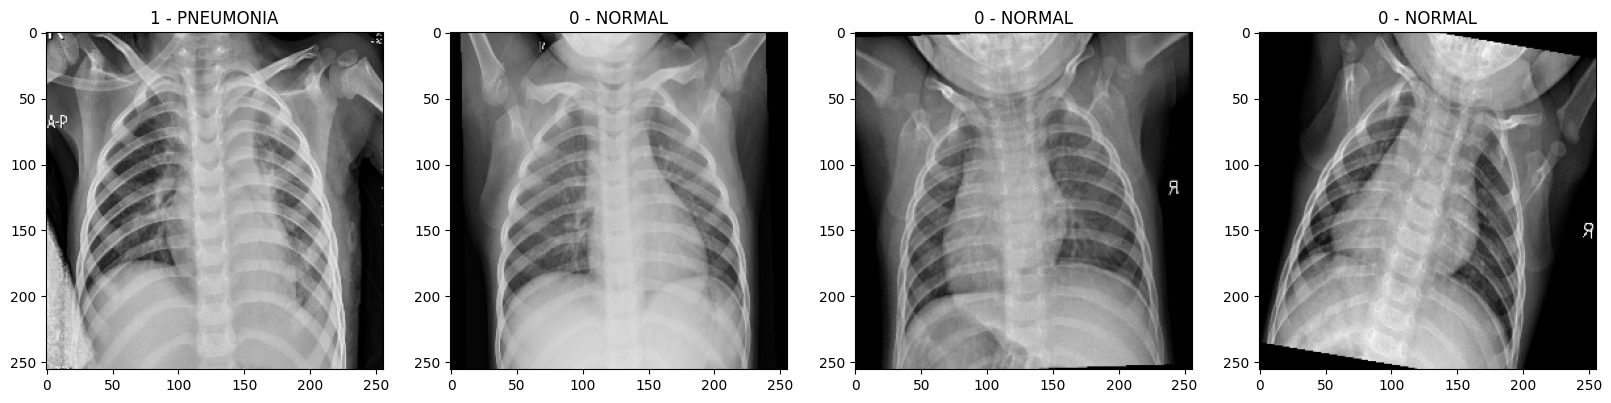

In [46]:
fig ,ax =plt.subplots(ncols=4,figsize=(20,20))
for idx , img in enumerate(batch[0][:4]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(f"{batch[1][idx]} - {class_names[batch[1][idx]]}")

In [ ]:
# class 0 : NORMAL
# class 1 : PNEUMONIA

# **PREPROCESSING DATA**

In [47]:
# scale the data values betwen 0 and 1
Train_data = data_train.map(lambda x,y: (x/255,y))

Val_data = data_val.map(lambda x,y: (x/255,y))

Test_data = data_test.map(lambda x,y: (x/255,y))

In [54]:
# normal data min=0 and max = 255
batch[0].max()

np.float32(255.0)

In [55]:
#scaled data min=0 and max = 1
scaled_batch = Train_data.as_numpy_iterator().next()
scaled_batch[0].max()

np.float32(1.0)

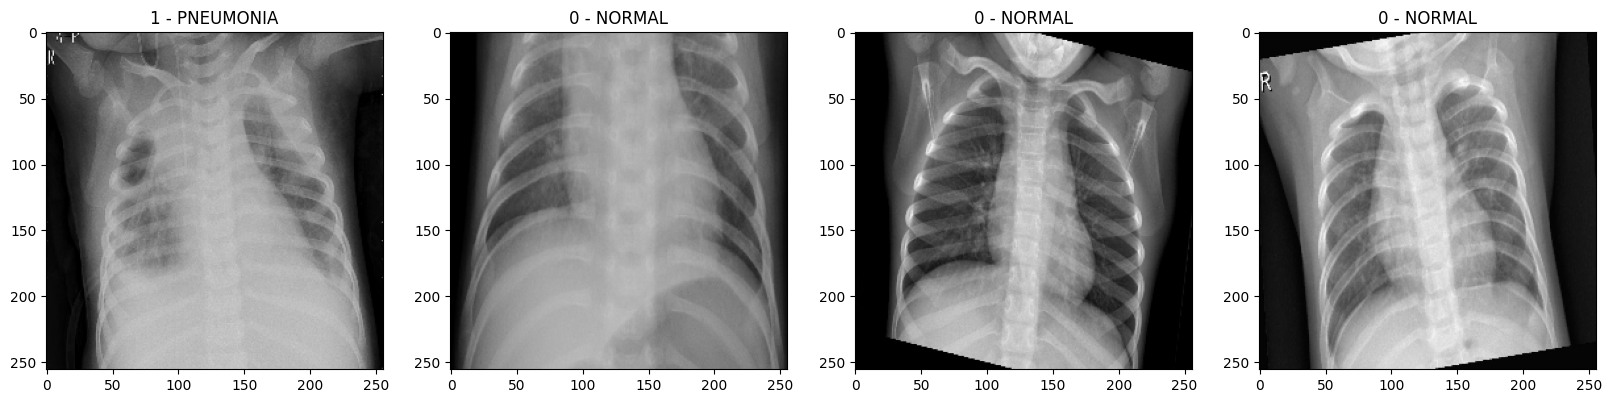

In [56]:
fig ,ax =plt.subplots(ncols=4,figsize=(20,20))
for idx , img in enumerate(scaled_batch[0][:4]):
    ax[idx].imshow(img)  # remove astype(int) because the values is betwen 0 and 1 so it gonna give a black image
    ax[idx].title.set_text(f"{batch[1][idx]} - {class_names[batch[1][idx]]}")

# **Building  the Deep Neural Network**

In [68]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten

In [69]:
model = Sequential()

In [70]:
model.add(Conv2D(16,(3,3),1,activation='relu',input_shape=(256,256,3)))
model.add(MaxPooling2D())

model.add(Conv2D(32,(3,3),1,activation='relu'))
model.add(MaxPooling2D())

model.add(Conv2D(16,(3,3),1,activation='relu'))
model.add(MaxPooling2D())

model.add(Flatten())

model.add(Dense(256,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [71]:
model.compile('adam',loss=tf.losses.BinaryCrossentropy(),metrics=['accuracy'])

In [72]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 254, 254, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 127, 127, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 125, 125, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 62, 62, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 60, 60, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 30, 30, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 14400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     3,686,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,696,625 (14.10 MB)

 Trainable params: 3,696,625 (14.10 MB)

 Non-trainable params: 0 (0.00 B)

In [75]:
# Create the logs folder
logdir = "/kaggle/working/logs"
os.makedirs(log_dir, exist_ok=True)

In [76]:
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)

In [78]:
hist =model.fit(Train_data, epochs=20 , validation_data=Val_data ,callbacks=[tensorboard_callback])

Epoch 1/20


I0000 00:00:1773854088.795783     568 service.cc:152] XLA service 0x7a4980002320 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773854088.795843     568 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1773854088.795848     568 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1773854089.540492     568 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-03-18 17:14:52.731198: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-18 17:14:53.005135: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1773854095.646656     568 device_co

212/213 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.8009 - loss: 0.4166

2026-03-18 17:15:20.126002: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-18 17:15:20.393487: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


213/213 ━━━━━━━━━━━━━━━━━━━━ 41s 150ms/step - accuracy: 0.8018 - loss: 0.4149 - val_accuracy: 0.9406 - val_loss: 0.1733
Epoch 2/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 27s 129ms/step - accuracy: 0.9553 - loss: 0.1185 - val_accuracy: 0.9482 - val_loss: 0.1542
Epoch 3/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 27s 127ms/step - accuracy: 0.9622 - loss: 0.0982 - val_accuracy: 0.9582 - val_loss: 0.1249
Epoch 4/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 27s 126ms/step - accuracy: 0.9751 - loss: 0.0704 - val_accuracy: 0.9624 - val_loss: 0.1197
Epoch 5/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 27s 129ms/step - accuracy: 0.9800 - loss: 0.0525 - val_accuracy: 0.9647 - val_loss: 0.1374
Epoch 6/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 27s 128ms/step - accuracy: 0.9855 - loss: 0.0389 - val_accuracy: 0.9629 - val_loss: 0.1276
Epoch 7/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 32s 150ms/step - accuracy: 0.9904 - loss: 0.0279 - val_accuracy: 0.9553 - val_loss: 0.1970
Epoch 8/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 27s 127ms/step - accuracy: 0.9909 - loss: 0.0251 - val